## Multi Level SubGraphs

In [2]:
# Grandchild graph
from typing_extensions import TypedDict
from langgraph.graph.state import StateGraph, START, END

class GrandChildState(TypedDict):
    my_grandchild_key: str

def grandchild_1(state: GrandChildState) -> GrandChildState:
    # NOTE: child or parent keys will not be accessible here
    return {"my_grandchild_key": state["my_grandchild_key"] + ", how are you"}


grandchild = StateGraph(GrandChildState)
grandchild.add_node("grandchild_1", grandchild_1)

grandchild.add_edge(START, "grandchild_1")
grandchild.add_edge("grandchild_1", END)

grandchild_graph = grandchild.compile()

# Child graph
class ChildState(TypedDict):
    my_child_key: str

def call_grandchild_graph(state: ChildState) -> ChildState:
    # NOTE: parent or grandchild keys won't be accessible here
    grandchild_graph_input = {"my_grandchild_key": state["my_child_key"]}
    grandchild_graph_output = grandchild_graph.invoke(grandchild_graph_input)
    return {"my_child_key": grandchild_graph_output["my_grandchild_key"] + " today?"}

child = StateGraph(ChildState)
# We're passing a function here instead of just compiled graph (`grandchild_graph`)
child.add_node("child_1", call_grandchild_graph)
child.add_edge(START, "child_1")
child.add_edge("child_1", END)
child_graph = child.compile()


# Parent graph
class ParentState(TypedDict):
    my_key: str

def parent_1(state: ParentState) -> ParentState:
    # NOTE: child or grandchild keys won't be accessible here
    return {"my_key": "hi " + state["my_key"]}


def call_child_graph(state: ParentState) -> ParentState:
    child_graph_input = {"my_child_key": state["my_key"]}
    child_graph_output = child_graph.invoke(child_graph_input)
    return {"my_key": child_graph_output["my_child_key"]}

def parent_2(state: ParentState) -> ParentState:
    return {"my_key": state["my_key"] + " bye!"}
    
parent = StateGraph(ParentState)
parent.add_node("parent_1", parent_1)
# We're passing a function here instead of just a compiled graph (`child_graph`)
parent.add_node("child", call_child_graph)
parent.add_node("parent_2", parent_2)

parent.add_edge(START, "parent_1")
parent.add_edge("parent_1", "child")
parent.add_edge("child", "parent_2")
parent.add_edge("parent_2", END)

parent_graph = parent.compile()

for chunk in parent_graph.stream({"my_key": "Bob"}, subgraphs=True):
    print(chunk)


((), {'parent_1': {'my_key': 'hi Bob'}})
(('child:377de051-f137-ef92-e017-52159eff65a3', 'child_1:c2ac86e9-fbf7-22b7-c16b-748c2f6917a9'), {'grandchild_1': {'my_grandchild_key': 'hi Bob, how are you'}})
(('child:377de051-f137-ef92-e017-52159eff65a3',), {'child_1': {'my_child_key': 'hi Bob, how are you today?'}})
((), {'child': {'my_key': 'hi Bob, how are you today?'}})
((), {'parent_2': {'my_key': 'hi Bob, how are you today? bye!'}})


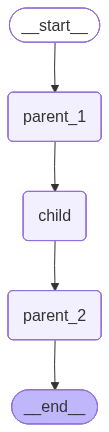

In [3]:
parent_graph